In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.size"] = 14

from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, BnBAlgorithm, LCBacquisition, EIacquisition, BnBNode

#### Example 

In [2]:
### parameters
n_samples = 3  # number of the initial samples to train GP
theta = 1.e-4# hyperparameter for GP kernel
nx = 1         # dimension of the problem
    
class PeriodicObjective(Problem):
    """
    f(x) = \sum_{i in dim(x)} \sin(2\pi * x_i)
    - Global minimizer: x* = (3/8,) * dim(x) + (1/2) * \mathbb{Z}^{dim(x)}
    - Global minimum:   f* = -dim(x)
    """
    def __init__(self, ndim=2, xlimits=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[0.0, 1.0]] * ndim, dtype=float)
        name = "PeriodicObjective"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)
        # expose known solution for checking later
        self.x_star = np.array([0.375,] * ndim)
        self.f_star = -1.0 * ndim

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, _ = x.shape
        y = np.sum(np.sin(4. * np.pi * x), axis=1).reshape(ne, 1)
        #in_range = [x >= 0.25 and x <= 0.75]
        in_range = [5./12. <= x[i,0] <= 11./12. for i in range(len(x))]
        y_update = np.zeros(y.shape)
        for i in range(len(y)):
            y_update[i,0] = y[i, 0]
            if in_range[i]:
                y_update[i, 0] *= np.cos(24. * np.pi * x[i,0])
        #y = np.array(y[i,0] * 1.)
        return y_update

problem = PeriodicObjective(ndim=nx)
problem.set_constraints([])  

problem.set_seed(42)
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

eval_noise=False
gp_model = smtKRG(theta, problem.xlimits, nx, pow_exp_power=2.0, 
                  eval_noise=eval_noise, 
                  noise0=1.e-6)
gp_model.train(x_train, y_train)

/home/tucker/anaconda3/envs/hiopbbpy/lib/python3.9/site-packages/smt/surrogate_models/krg_based.py:2490: UserWarning: TNC not available yet for noise handling. Switching to Cobyla
  warnings.warn(


max pointwise standard dev =  [0.81490405]


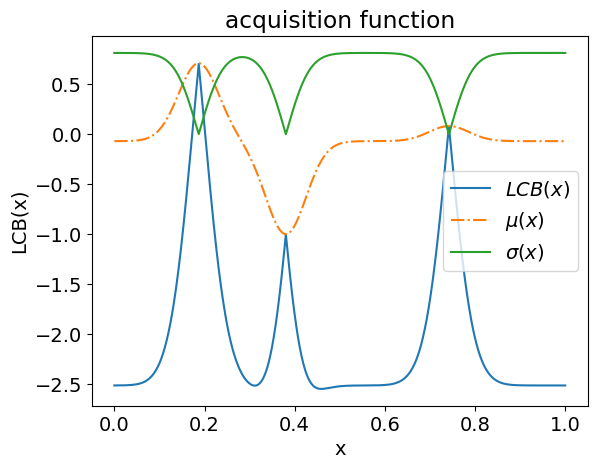

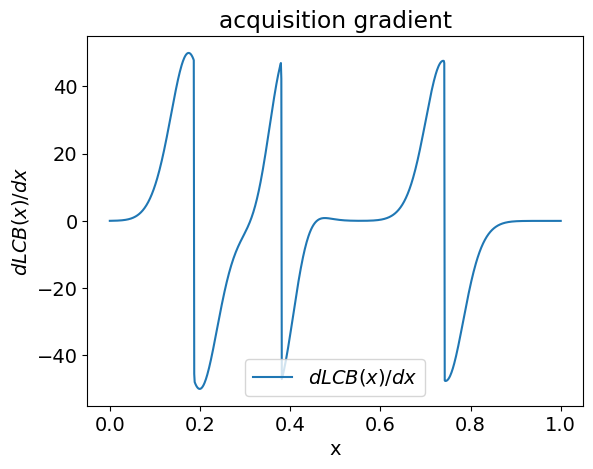

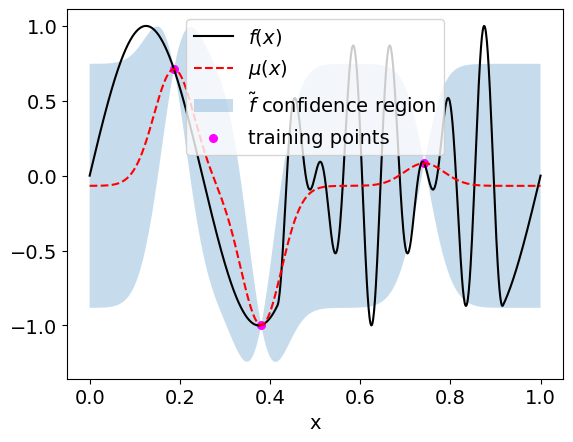

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
print("max pointwise standard dev = ", max(sigmaX))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)
Y_true = problem.evaluate(X)
Y_grad = np.array([acqf.scalar_eval_g(X[i]) for i in range(X.shape[0])]).flatten()

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

plt.plot(X, Y_grad, label=r'$dLCB(x)/dx$')
plt.xlabel("x")
plt.ylabel(r"$d LCB(x)/dx$")
plt.legend()
plt.title("acquisition gradient")
plt.show()


import matplotlib.pyplot as plt2
plt.plot(X, Y_true, 'k', label=r'$f(x)$')
plt.plot(X, muX, 'r--', label=r'$\mu(x)$')
plt2.fill_between(X.flatten(), (muX-sigmaX).flatten(), (muX + sigmaX).flatten(),
                 label=r'$\tilde{f}$ confidence region', alpha=0.25)
plt.scatter(x_train, y_train, marker='o', s=30, c='magenta', label='training points')
plt.xlabel("x")
plt.legend()
plt.show()
plt.close()

In [4]:
bnb_options = {
    'opt_mode' : 2,
}
bnb = BnBAlgorithm(acqf)
bnb.initialize()
root = bnb.best_node


Initial acquisition lower bound: -2.5473510642510684
Initial acquisition upper bound: -2.520854336365171


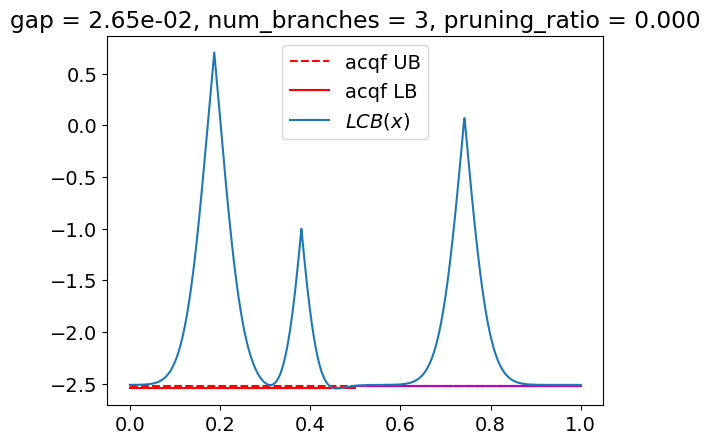

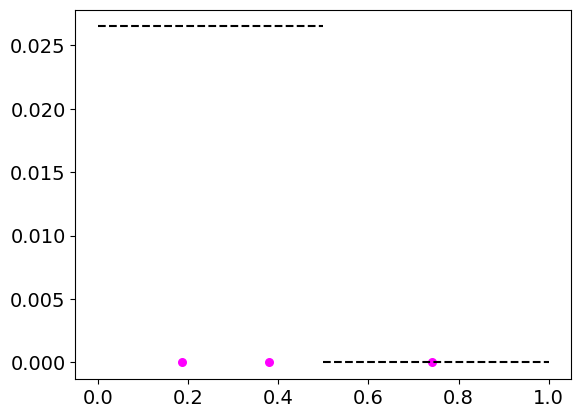

gap failure
improper lower-bound comp
acqf_L =  -2.520854331975957
acqf_min =  -2.520854336365171
relative error =  1.7411614237328832e-09
node: 0.5 0.75
trainint pt [0.74201465] is in the node
gap failure
improper lower-bound comp
acqf_L =  -2.5126747560998486
acqf_min =  -2.512674765951139
relative error =  3.92063890780906e-09
node: 0.75 1.0


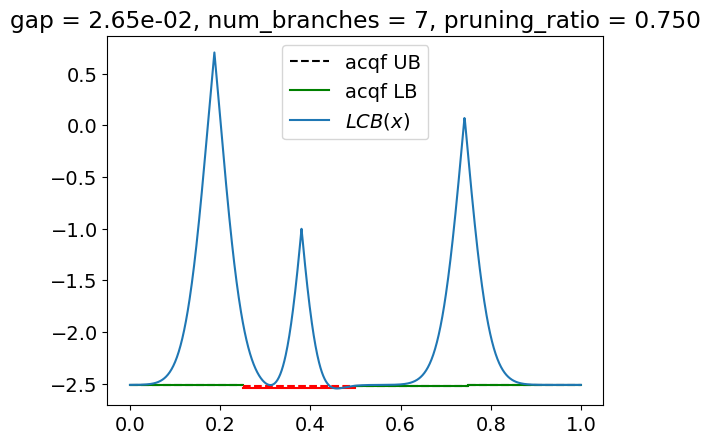

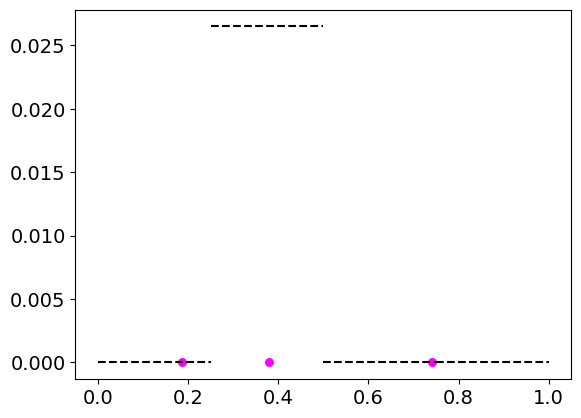

gap failure
improper lower-bound comp
acqf_L =  -1.9019957470662086
acqf_min =  -1.9019957798949059
relative error =  1.7260131522451625e-08
node: 0.125 0.25
trainint pt [0.18704052] is in the node
gap failure
improper lower-bound comp
acqf_L =  -2.520854330193591
acqf_min =  -2.520854336365171
relative error =  2.4482097385786872e-09
node: 0.5 0.625
gap failure
improper lower-bound comp
acqf_L =  -2.4878192107891923
acqf_min =  -2.4878192143780167
relative error =  1.4425583370644945e-09
node: 0.625 0.75
trainint pt [0.74201465] is in the node
gap failure
improper lower-bound comp
acqf_L =  -2.5037504142817664
acqf_min =  -2.503750420372781
relative error =  2.432756377825099e-09
node: 0.75 0.875
gap failure
improper lower-bound comp
acqf_L =  -2.512674734699875
acqf_min =  -2.512674765951139
relative error =  1.2437448995215278e-08
node: 0.875 1.0


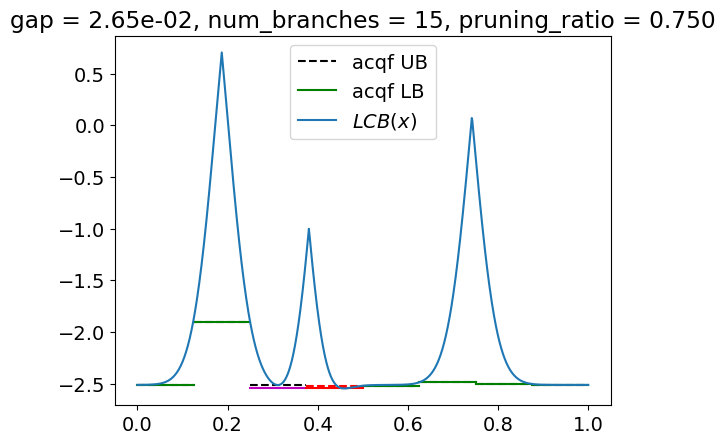

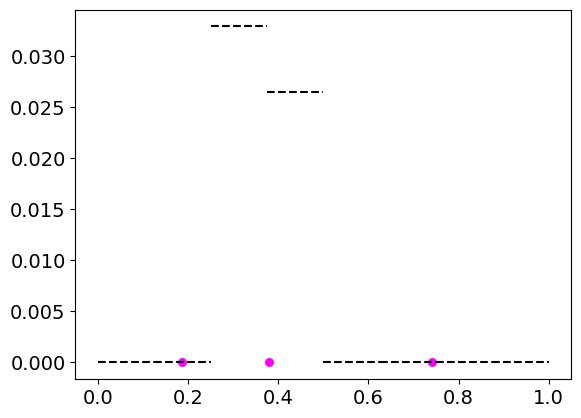

gap failure
improper lower-bound comp
acqf_L =  -2.5124687808952304
acqf_min =  -2.5124687875194947
relative error =  2.636555837489634e-09
node: 0.0 0.0625
gap failure
improper lower-bound comp
acqf_L =  -1.9019957658187088
acqf_min =  -1.9019957798949059
relative error =  7.4007509614929976e-09
node: 0.1875 0.25
gap failure
improper lower-bound comp
acqf_L =  -2.497514233836036
acqf_min =  -2.4975142611839125
relative error =  1.0950038137094644e-08
node: 0.375 0.4375
trainint pt [0.38046736] is in the node
gap failure
improper lower-bound comp
acqf_L =  -2.5208543335172227
acqf_min =  -2.520854336365171
relative error =  1.1297552986607774e-09
node: 0.5 0.5625
gap failure
improper lower-bound comp
acqf_L =  -2.5125237428339795
acqf_min =  -2.5125237470020583
relative error =  1.6589211449203912e-09
node: 0.5625 0.625
gap failure
improper lower-bound comp
acqf_L =  -2.4878192107870802
acqf_min =  -2.4878192143780167
relative error =  1.4434073088345655e-09
node: 0.625 0.6875
gap fail

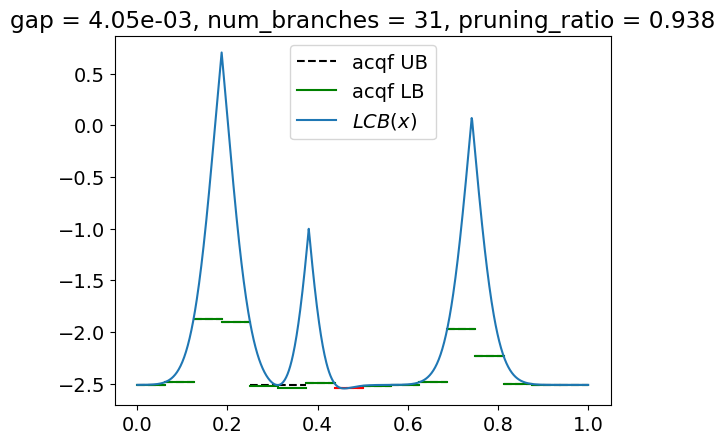

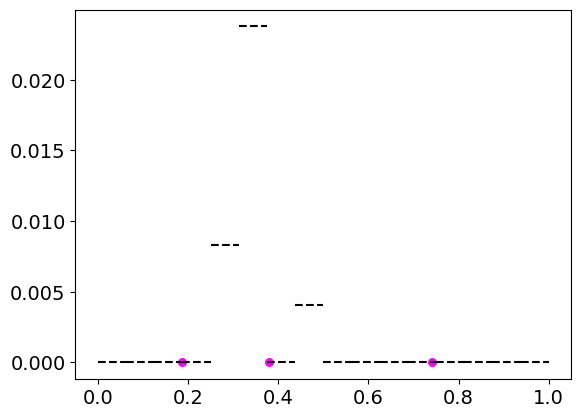

gap failure
improper lower-bound comp
acqf_L =  -2.5124687642079233
acqf_min =  -2.5124687875194947
relative error =  9.278352613072922e-09
node: 0.0 0.03125
gap failure
improper lower-bound comp
acqf_L =  -2.5096057041858337
acqf_min =  -2.50960571447308
relative error =  4.0991483668938175e-09
node: 0.03125 0.0625
gap failure
improper lower-bound comp
acqf_L =  -2.484508837584592
acqf_min =  -2.4845088388475505
relative error =  5.08333319979138e-10
node: 0.0625 0.09375
gap failure
improper lower-bound comp
acqf_L =  -0.8268833144060238
acqf_min =  -0.8268833197275534
relative error =  6.4356474769668355e-09
node: 0.1875 0.21875
gap failure
improper lower-bound comp
acqf_L =  -1.9019957633141804
acqf_min =  -1.9019957798949059
relative error =  8.717540614211128e-09
node: 0.21875 0.25
gap failure
improper lower-bound comp
acqf_L =  -2.3818489202932445
acqf_min =  -2.3818489222809127
relative error =  8.345064347359946e-10
node: 0.25 0.28125
gap failure
improper lower-bound comp
acqf_

/home/tucker/anaconda3/envs/hiopbbpy/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


gap failure
improper lower-bound comp
acqf_L =  -2.5208543300924524
acqf_min =  -2.520854336365171
relative error =  2.4883305228497547e-09
node: 0.5 0.53125
gap failure
improper lower-bound comp
acqf_L =  -2.513691488211423
acqf_min =  -2.513691493382462
relative error =  2.0571494815663825e-09
node: 0.53125 0.5625
gap failure
improper lower-bound comp
acqf_L =  -2.512523744435757
acqf_min =  -2.5125237470020583
relative error =  1.0214038361531992e-09
node: 0.5625 0.59375
gap failure
improper lower-bound comp
acqf_L =  -2.50967753896802
acqf_min =  -2.509677540926989
relative error =  7.805660110032619e-10
node: 0.59375 0.625
gap failure
improper lower-bound comp
acqf_L =  -2.4878192098701253
acqf_min =  -2.4878192143780167
relative error =  1.811985118311147e-09
node: 0.625 0.65625
gap failure
improper lower-bound comp
acqf_L =  -2.3757416123972925
acqf_min =  -2.3757416179790085
relative error =  2.349462557741092e-09
node: 0.65625 0.6875
gap failure
improper lower-bound comp
acqf_

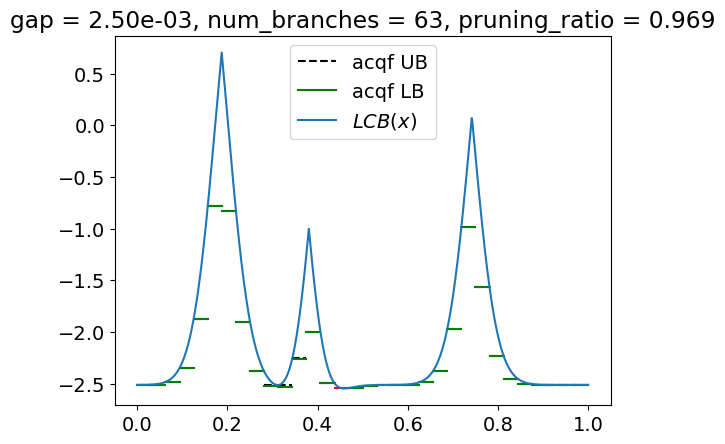

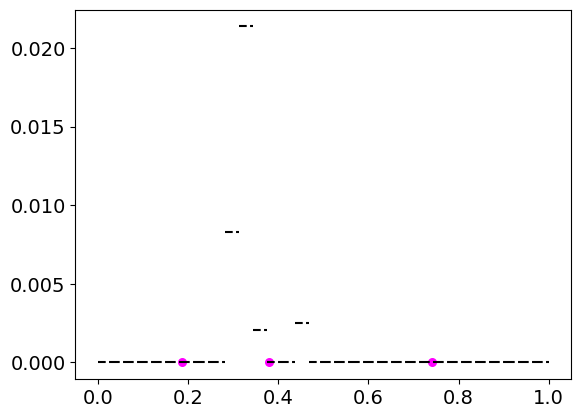

gap failure
improper lower-bound comp
acqf_L =  -2.5124687732164803
acqf_min =  -2.5124687875194947
relative error =  5.692812742401147e-09
node: 0.0 0.015625
gap failure
improper lower-bound comp
acqf_L =  -2.511829399015191
acqf_min =  -2.5118294134766015
relative error =  5.757321820462603e-09
node: 0.015625 0.03125
gap failure
improper lower-bound comp
acqf_L =  -2.5096057084624888
acqf_min =  -2.50960571447308
relative error =  2.3950340490760006e-09
node: 0.03125 0.046875
gap failure
improper lower-bound comp
acqf_L =  -2.5028070435060146
acqf_min =  -2.5028070567314433
relative error =  5.284238238253301e-09
node: 0.046875 0.0625
gap failure
improper lower-bound comp
acqf_L =  -2.484508832820798
acqf_min =  -2.4845088388475505
relative error =  2.4257319338976984e-09
node: 0.0625 0.078125
gap failure
improper lower-bound comp
acqf_L =  -2.4409785424822195
acqf_min =  -2.440978548297867
relative error =  2.382506607102038e-09
node: 0.078125 0.09375
gap failure
improper lower-boun

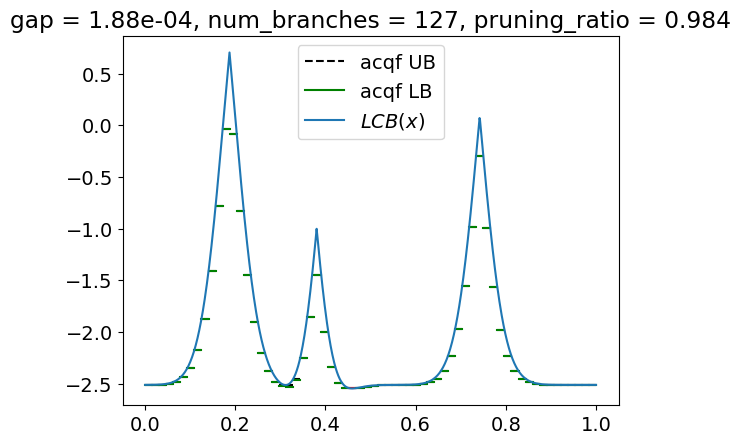

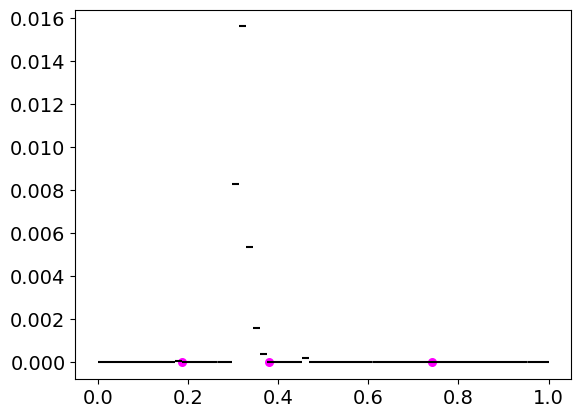

gap failure
improper lower-bound comp
acqf_L =  -2.5124687668733534
acqf_min =  -2.5124687875194947
relative error =  8.217471732841274e-09
node: 0.0 0.0078125
gap failure
improper lower-bound comp
acqf_L =  -2.5122510136685445
acqf_min =  -2.512251019495604
relative error =  2.319457424564784e-09
node: 0.0078125 0.015625
gap failure
improper lower-bound comp
acqf_L =  -2.5118293991143563
acqf_min =  -2.5118294134766015
relative error =  5.717842578748387e-09
node: 0.015625 0.0234375
gap failure
improper lower-bound comp
acqf_L =  -2.511039246283126
acqf_min =  -2.5110392506589716
relative error =  1.742643195484545e-09
node: 0.0234375 0.03125
gap failure
improper lower-bound comp
acqf_L =  -2.5096057058390486
acqf_min =  -2.50960571447308
relative error =  3.4403935319101765e-09
node: 0.03125 0.0390625
gap failure
improper lower-bound comp
acqf_L =  -2.507088044077951
acqf_min =  -2.5070880502216135
relative error =  2.4505172313781456e-09
node: 0.0390625 0.046875
gap failure
improper

/home/tucker/anaconda3/envs/hiopbbpy/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


gap failure
improper lower-bound comp
acqf_L =  -2.3818489218316032
acqf_min =  -2.3818489222809127
relative error =  1.8863894947693876e-10
node: 0.2734375 0.28125
gap failure
improper lower-bound comp
acqf_L =  -2.4402906000055316
acqf_min =  -2.4402906063763945
relative error =  2.610698468311458e-09
node: 0.28125 0.2890625
gap failure
improper lower-bound comp
acqf_L =  -2.4817013695457826
acqf_min =  -2.481701377182936
relative error =  3.0773862022356933e-09
node: 0.2890625 0.296875
gap failure
improper lower-bound comp
acqf_L =  -1.9996190257930704
acqf_min =  -1.9996190263186218
relative error =  2.6282575494407284e-10
node: 0.3984375 0.40625
gap failure
improper lower-bound comp
acqf_L =  -2.194527883304118
acqf_min =  -2.19452788945177
relative error =  2.801355020627317e-09
node: 0.40625 0.4140625
gap failure
improper lower-bound comp
acqf_L =  -2.3381253999862484
acqf_min =  -2.338125406289672
relative error =  2.695930485138797e-09
node: 0.4140625 0.421875
gap failure
impr

/home/tucker/anaconda3/envs/hiopbbpy/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


gap failure
improper lower-bound comp
acqf_L =  -2.5370374634133754
acqf_min =  -2.537037465554625
relative error =  8.439959713183033e-10
node: 0.4765625 0.484375
gap failure
improper lower-bound comp
acqf_L =  -2.5306086950049216
acqf_min =  -2.5306086969894386
relative error =  7.842053959350642e-10
node: 0.484375 0.4921875
gap failure
improper lower-bound comp
acqf_L =  -2.525097547074326
acqf_min =  -2.5250975510992015
relative error =  1.5939485356555649e-09
node: 0.4921875 0.5
gap failure
improper lower-bound comp
acqf_L =  -2.5208543351800374
acqf_min =  -2.520854336365171
relative error =  4.701317929414173e-10
node: 0.5 0.5078125
gap failure
improper lower-bound comp
acqf_L =  -2.5178274060175045
acqf_min =  -2.5178274447602633
relative error =  1.5387376469954242e-08
node: 0.5078125 0.515625
gap failure
improper lower-bound comp
acqf_L =  -2.5157932810941896
acqf_min =  -2.5157932973101818
relative error =  6.4456774417834694e-09
node: 0.515625 0.5234375
gap failure
improper

gap failure
improper lower-bound comp
acqf_L =  -2.512664718035121
acqf_min =  -2.5126647227597396
relative error =  1.8803218875292615e-09
node: 0.9453125 0.953125
gap failure
improper lower-bound comp
acqf_L =  -2.512670449285551
acqf_min =  -2.5126704819290224
relative error =  1.2991544938436522e-08
node: 0.953125 0.9609375
gap failure
improper lower-bound comp
acqf_L =  -2.5126730062403655
acqf_min =  -2.512673007664965
relative error =  5.669657552303746e-10
node: 0.9609375 0.96875
gap failure
improper lower-bound comp
acqf_L =  -2.512674073269777
acqf_min =  -2.512674080556497
relative error =  2.899986183074849e-09
node: 0.96875 0.9765625
gap failure
improper lower-bound comp
acqf_L =  -2.5126744762978297
acqf_min =  -2.5126745220228743
relative error =  1.8197758698448136e-08
node: 0.9765625 0.984375
gap failure
improper lower-bound comp
acqf_L =  -2.5126746489776695
acqf_min =  -2.5126746979953882
relative error =  1.9508183376051597e-08
node: 0.984375 0.9921875
gap failure
i

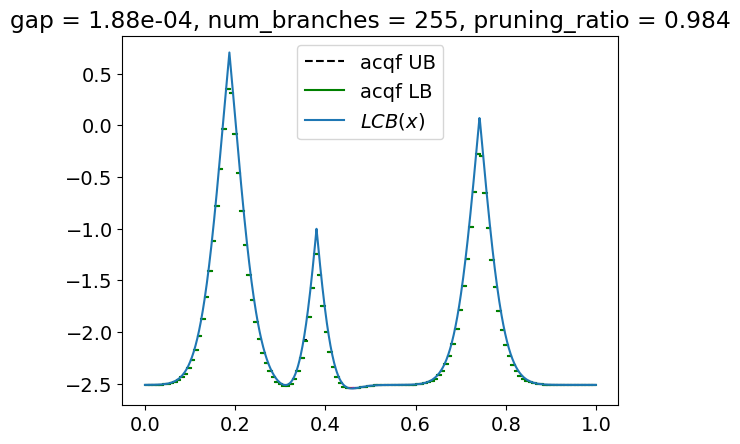

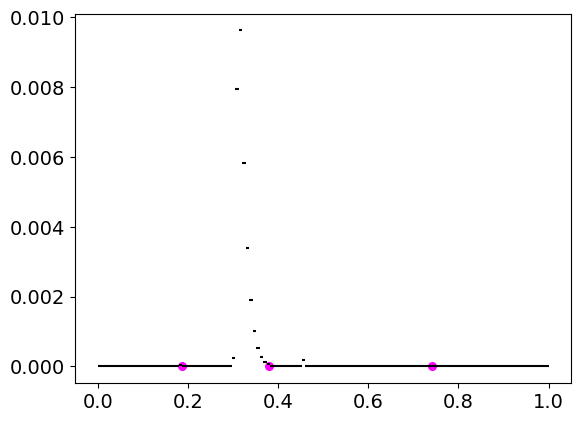

In [5]:
from hiopbbpy.opt.bnbalgorithm import branch
nodes = [root]

num_divisions = 7
num_branches = 1
LUBgaps = np.zeros(num_divisions)
min_gaps = np.zeros(num_divisions)
max_gaps = np.zeros(num_divisions)
avg_gaps = np.zeros(num_divisions)
std_gaps = np.zeros(num_divisions)
pruning_ratios = np.zeros(num_divisions)
all_all_gaps = []

for j in range(num_divisions):
    children = []
    for node in nodes:
        for child_l, child_u in branch(node.l, node.u):
            acqf_L, acqf_U = bnb.compute_acqf_bounds(child_l, child_u)
            
            child = BnBNode(child_l, child_u, acqf_L, acqf_U)
            children.append(child)
            if acqf_U - acqf_L < 0.:
                print("gap failure")
                pts = np.atleast_2d(np.linspace(child_l[0], child_u[0], num =200)).T
                acqf_pts = acqf.evaluate(pts).flatten()
                acqf_min = min(acqf_pts)
                if acqf_L > acqf_min:
                    print("improper lower-bound comp")
                    print("acqf_L = ", acqf_L)
                    print("acqf_min = ", acqf_min)
                    print("relative error = ", abs(acqf_L - acqf_min) / abs(acqf_min))
                if acqf_U < acqf_min:
                    print("local acqf_U optimizer did not converge to global nodal min")
                print("node:", child_l[0], child_u[0])
                for train_pt in x_train:
                    if child_l[0] <= train_pt[0] and train_pt[0] <= child_u[0]:
                        print("trainint pt", train_pt, "is in the node")
            
    num_branches += len(children)

    min_idx = np.argmin([child.aq_U for child in children])        
    LUB = children[min_idx].aq_U
    LUBgap = children[min_idx].aq_U - children[min_idx].aq_L
    all_gaps = np.array([child.aq_U - child.aq_L for child in children])
    min_gaps[j] = min(all_gaps)
    max_gaps[j] = max(all_gaps)
    avg_gaps[j] = np.mean(all_gaps)
    std_gaps[j] = np.std(all_gaps)
    LUBgaps[j] = LUBgap
    all_all_gaps.append(all_gaps)
    
    pruning_ratio = 0.
    for i, child in enumerate(children):
        if child.aq_L > LUB:
            pruning_ratio += 1.
    pruning_ratio /= len(children)
    pruning_ratios[j] = pruning_ratio
    for i, child in enumerate(children):
        xplt = np.linspace(child.l[0], child.u[0], num=10)
        acqf_UB = child.aq_U * np.ones(10)
        acqf_LB = child.aq_L * np.ones(10)
        if i == min_idx:
            ub_color = 'r'
            lb_color = 'r'
        elif child.aq_L > LUB:
            ub_color = 'k'
            lb_color = 'g'
        else:
            ub_color = 'k'
            lb_color = 'm'
        
        if i == 0:
            plt.plot(xplt, acqf_UB, "--" + ub_color, label="acqf UB")
            plt.plot(xplt, acqf_LB, "-" + lb_color, label="acqf LB")
        else:
            plt.plot(xplt, acqf_UB, "--" + ub_color)
            plt.plot(xplt, acqf_LB, "-" + lb_color)
    plt.plot(X, Y_acqf, label=r'$LCB(x)$')
    plt.title('gap = {0:1.2e}, num_branches = {1:d}, pruning_ratio = {2:1.3f}'.format(
        LUBgap, num_branches, pruning_ratio))
    plt.legend()
    plt.savefig('data_bounds/ublb'+str(j) + 'divisions.png')
    plt.show()
    plt.close()
    for i, child in enumerate(children):
        xplt = np.linspace(child.l[0], child.u[0], num=10)
        Y_gap = (child.aq_U - child.aq_L) * np.ones(10)
        plt.plot(xplt, Y_gap, '--k')
    plt.scatter(x_train, np.zeros(x_train.shape[0]), marker='o', s=30, c='magenta', label='training points')
    plt.show()  
    nodes = children

In [6]:
x_train2 = np.atleast_2d(np.sort(x_train.flatten())).T

gap_nplt_points = 10
deltas = np.logspace(-5, -2, num = gap_nplt_points)
all_gaps_v_deltas = []
for train_pt in x_train2:
    gaps = np.zeros(len(deltas))
    for i, delta_scalar in enumerate(deltas):
        delta = np.ones(train_pt.shape[0]) * delta_scalar
        lbox = train_pt - delta
        ubox = train_pt + delta
        acqf_L, acqf_U = bnb.compute_acqf_bounds(lbox, ubox)
        gaps[i] = acqf_U - acqf_L
        if gaps[i] < 0.:
            print("gap failure")
            pts = np.atleast_2d(np.linspace(lbox[0], ubox[0], num =1000)).T
            acqf_pts = acqf.evaluate(pts).flatten()
            acqf_min = min(acqf_pts)
            if acqf_L > acqf_min:
                print("improper lower-bound comp")
                print("acqf_L = ", acqf_L)
                print("acqf_min = ", acqf_min)
                print("relative error = ", abs(acqf_L - acqf_min) / abs(acqf_min))
            if acqf_U > acqf_min:
                print("local acqf_U optimizer did not converge to global nodal min")
    all_gaps_v_deltas.append(gaps)

gap failure
improper lower-bound comp
acqf_L =  0.22127866694707155
acqf_min =  0.2212786662031201
relative error =  3.3620568523850224e-09


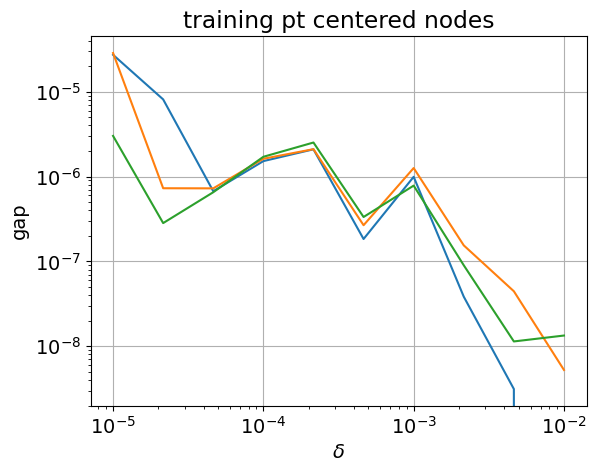

In [7]:
for i, gaps in enumerate(all_gaps_v_deltas):
    if i == 5:
        plt.plot(deltas, gaps, '--k')
    else:
        plt.plot(deltas, gaps)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\delta$')
plt.ylabel('gap')
plt.title('training pt centered nodes')
plt.grid()
plt.show()

In [11]:
x_train2 = np.atleast_2d(np.sort(x_train.flatten())).T
midpts_train = [(x_train2[i] + x_train2[i+1]) / 2. for i in range(x_train2.shape[0]-1)]
midpts_train = np.array(midpts_train)

gap_nplt_points = 30
deltas = np.logspace(-5, -2, num = gap_nplt_points)
all_midpt_gaps_v_deltas = []
for midpt in midpts_train:
    gaps = np.zeros(len(deltas))
    for i, delta_scalar in enumerate(deltas):
        delta = delta_scalar * np.ones(midpt.shape[0]) 
        lbox = midpt - delta
        ubox = midpt + delta
        acqf_L, acqf_U = bnb.compute_acqf_bounds(lbox, ubox)
        gaps[i] = acqf_U - acqf_L
        if gaps[i] < 0.:
            print("gap failure")
            pts = np.atleast_2d(np.linspace(lbox[0], ubox[0], num =200)).T
            acqf_pts = acqf.evaluate(pts).flatten()
            acqf_min = min(acqf_pts)
            if acqf_L > acqf_min:
                print("improper lower-bound comp")
                print("acqf_L = ", acqf_L)
                print("acqf_min = ", acqf_min)
                print("relative error = ", abs(acqf_L - acqf_min) / abs(acqf_min))
            if acqf_U > acqf_min:
                print("local acqf_U optimizer did not converge to global nodal min")
    all_midpt_gaps_v_deltas.append(gaps)

gap failure
improper lower-bound comp
acqf_L =  -2.402652196431444
acqf_min =  -2.4026522052846335
relative error =  3.6847570852725276e-09
gap failure
improper lower-bound comp
acqf_L =  -2.402673392397215
acqf_min =  -2.4026734084649224
relative error =  6.687428908257077e-09
gap failure
improper lower-bound comp
acqf_L =  -2.4027003081906892
acqf_min =  -2.4027003112932124
relative error =  1.2912651289525276e-09
gap failure
improper lower-bound comp
acqf_L =  -2.4027344373876285
acqf_min =  -2.4027344448119186
relative error =  3.089933674377675e-09
gap failure
improper lower-bound comp
acqf_L =  -2.4027777438407485
acqf_min =  -2.4027777506702876
relative error =  2.8423515884989808e-09
gap failure
improper lower-bound comp
acqf_L =  -2.4028326822271424
acqf_min =  -2.4028326908395714
relative error =  3.584281596062685e-09
gap failure
improper lower-bound comp
acqf_L =  -2.402902375656756
acqf_min =  -2.402902386397134
relative error =  4.469752071982693e-09
gap failure
improper 

/home/tucker/anaconda3/envs/hiopbbpy/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


gap failure
improper lower-bound comp
acqf_L =  -2.5125578892840394
acqf_min =  -2.512557895112357
relative error =  2.319674860272384e-09
gap failure
improper lower-bound comp
acqf_L =  -2.5125580350871344
acqf_min =  -2.512558038298416
relative error =  1.278092451604338e-09
gap failure
improper lower-bound comp
acqf_L =  -2.51255821674387
acqf_min =  -2.5125582199562015
relative error =  1.2785103678132086e-09
gap failure
improper lower-bound comp
acqf_L =  -2.5125584471434803
acqf_min =  -2.512558450408945
relative error =  1.2996572425725364e-09
gap failure
improper lower-bound comp
acqf_L =  -2.5125587396721696
acqf_min =  -2.5125587427417684
relative error =  1.2217023009848556e-09
gap failure
improper lower-bound comp
acqf_L =  -2.512559110434432
acqf_min =  -2.512559113535682
relative error =  1.2342994642051576e-09
gap failure
improper lower-bound comp
acqf_L =  -2.5125595810918284
acqf_min =  -2.5125595837936916
relative error =  1.075342927213214e-09
gap failure
improper lo

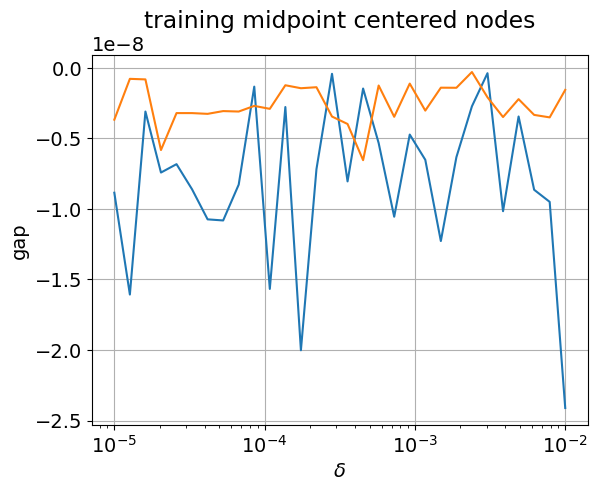

In [12]:
for i, gaps in enumerate(all_midpt_gaps_v_deltas):
    plt.plot(deltas, gaps)
#plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\delta$')
plt.ylabel('gap')
plt.title('training midpoint centered nodes')
plt.grid()
plt.show()

In [ ]:
pos_gap_sets = []
for gap_set in all_all_gaps:
    pos_gaps = []
    for i, gap in enumerate(gap_set):
        if gap > 0.:
            pos_gaps.append(gap)
        else:
            print("failure at = ", i / len(gap_set))            
    print(min(pos_gaps))
print(x_train2)

In [ ]:
plt.plot(range(1, num_divisions+1), LUBgaps)
plt.yscale('log')
plt.ylabel('LUB gap')
plt.xlabel('num divisions')
plt.show()

plt.plot(range(1, num_divisions+1), avg_gaps, label='mean gap')
plt.plot(range(1, num_divisions+1), avg_gaps + std_gaps)
plt.plot(range(1, num_divisions+1), avg_gaps - std_gaps)
plt.yscale('log')
plt.ylabel('gap')
plt.xlabel('num divisions')
plt.show()


np.savetxt('data_bounds/LUBgapsvsdivisions.dat', LUBgaps)
np.savetxt('data_bounds/avggapsvsdivisions.dat', avg_gaps)
np.savetxt('data_bounds/stdgapsvsdivisions.dat', std_gaps)
np.savetxt('data_bounds/pruningratios.dat', pruning_ratios)
for i in range(num_divisions):
    np.savetxt('data_bounds/allgaps_'+str(i)+'.dat', all_all_gaps[i])


In [ ]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 100
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)
LCB_Us_sample = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i+1) * box_sizes[0]
        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = acqf.evaluate_meansig2(np.atleast_1d(mu_L), np.atleast_1d(s2_U))[0]
        LCB_U = acqf.evaluate_meansig2(np.atleast_1d(mu_U), np.atleast_1d(s2_L))[0]
        #LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        x_pts = np.atleast_2d(np.linspace(li, ui, num=200))
        LCB_U_sample = min(acqf.evaluate(x_pts).flatten())
        #print(LCB_U_sample)
        
        
        
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            LCB_Us_sample[i] = LCB_U_sample
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

In [ ]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

In [ ]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

In [ ]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(X, sigmaX**2., label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, "k--", label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [ ]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(midpoints, LCB_Us_sample, "--", label=r"LCB$_{U}(x)$ (sample)")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')  
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [ ]:
from hiopbbpy.opt import BnBAlgorithm

solver_options = {
    'epsilon_diam' : 1.e-12,
    'epsilon_gap' : 1.e-2,    
    'max_iter': 10000,
}
bnb = BnBAlgorithm(acqf, options=solver_options)
bnb.initialize()
xstar = bnb.optimize()

In [ ]:
y_star = acqf.evaluate(xstar)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
#plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()

In [ ]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': 'BnB',
    'solver_options' : solver_options,
}

In [ ]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

In [ ]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
#x_train_superset = np.concatenate((x_train, np.atleast_2d(xstar)), axis=0)
#bo_maxiter = 1
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$\min_{x}\,\lbrace LCB(x)\rbrace$')
    plt.plot(x_bo[i], y_star2, r'b*', markersize=14, label=r'global minimizer')
    plt.xlabel("x")
    #plt.ylabel("LCB(x)")
    plt.legend()
    #plt.title(r"BO iteration {0:d}".format(i))
    plt.savefig('acqf_iter'+str(i)+'.png')
    plt.show()
#y_train2 = problem.evaluate(x_train_superset)
#gp_model2 = smtKRG(theta, problem.xlimits, nx)
#gp_model2.train(x_train_superset, y_train2)
#acqf2 = LCBacquisition(gp_model2, beta=beta)
#Y_acqf2 = acqf2.evaluate(X)

In [ ]:
#x_train_superset = 
x_train_superset = np.concatenate((x_train, np.atleast_2d(xstar)), axis=0)

y_train2 = problem.evaluate(x_train_superset)
gp_model2 = smtKRG(theta, problem.xlimits, nx)
gp_model2.train(x_train_superset, y_train2)
acqf2 = LCBacquisition(gp_model2, beta=beta)
Y_acqf2 = acqf2.evaluate(X)
muX = gp_model2.mean(X)
sigmaX = np.sqrt(gp_model2.variance(X))

yat_xstar = problem.evaluate(np.atleast_2d(xstar))

import matplotlib.pyplot as plt2
plt.plot(X, Y_true, 'k', label=r'$f(x)$')
plt.plot(X, muX, 'r--', label=r'$\mu(x)$')
plt2.fill_between(X.flatten(), (muX-sigmaX).flatten(), (muX + sigmaX).flatten(),
                 label=r'$\tilde{f}$ confidence region', alpha=0.25)
plt.scatter(x_train_superset, y_train2, marker='o', s=30, c='magenta', label='training points')
plt.plot(xstar, yat_xstar, r'b*', markersize=14)
plt.xlabel("x")
plt.legend()
#plt.grid()
plt.savefig('post.png')
plt.show()